# 02 — Taxonomy structure

Notebook 01 compared 373 individual topics. That is the finest resolution available, but it
is not the level at which romance scholarship makes claims. Nobody theorises about
"Promising to Find Her"; they theorise about *relationship repair*, or *explicit sexuality*,
or *conflict*.

So this chapter moves up. Each topic carries a taxonomy label from Stage 09 — a leaf
category such as `4.6 Care, Protection & Emotional Safety` — and each leaf belongs to one of
eleven main groups. This gives two coarser views of the same corpus:

1. **Main groups** — twelve broad domains. What is a romance novel made of, and does the mix
   differ between well-rated and poorly-rated books?
2. **Subgroups (leaves)** — 45 categories, presented as one panel per main group, so each
   domain can be read on its own terms.

**The risk this chapter has to check.** Grouping can destroy signal as easily as it reveals
it. If two topics inside one category move in opposite directions with rating, their sum
will show nothing at all, and the honest conclusion is "the category is the wrong unit"
rather than "the theme does not matter". Section 4 tests for exactly that, and notebook 03
follows up wherever it fires.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import tests as tst

ctx = nbh.setup("02_taxonomy_structure")
cfg = ctx.cfg
TIERS = cfg.tier_order
TIER_COL = cfg.tier_column
PALETTE = nbh.tier_palette(cfg)
HIGH, LOW = cfg.section("tiers", "headline_contrast")
ALPHA = float(cfg.section("inference", "fdr_alpha"))
GATE = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
REPLICATES = int(cfg.section("inference", "effect_ci_replicates"))

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
GROUP_COLS = nbh.columns_with_prefix(frame, "group_")
LEAF_COLS = nbh.columns_with_prefix(frame, "leaf_")

# The leaf/group naming has to be reconstructed from the lookup, because column names are
# slugified ids: `leaf_4.6`, `group_relationship_trajectory_(main_couple)`.
leaf_meta = (
    topic_lookup.dropna(subset=["taxonomy_main_id"])
    .groupby("taxonomy_main_id")
    .agg(leaf_name=("taxonomy_main_name", "first"),
         main_group=("taxonomy_main_group", "first"),
         n_topics=("topic_id", "size"))
    .reset_index().rename(columns={"taxonomy_main_id": "leaf_id"})
)
leaf_meta["feature"] = "leaf_" + leaf_meta["leaf_id"].astype(str)
# `uncertain_interpretable` and `unmapped` are bookkeeping ids, not categories: they exist in
# the absolute-share block for accounting but are not part of the conditional composition.
leaf_meta = leaf_meta[leaf_meta["feature"].isin(LEAF_COLS)].reset_index(drop=True)
LEAF_NAME = dict(zip(leaf_meta["feature"], leaf_meta["leaf_name"]))
LEAF_GROUP = dict(zip(leaf_meta["feature"], leaf_meta["main_group"]))


def group_slug(name: str) -> str:
    """Reproduce the column naming used by 02_book_aggregation.py."""
    return "group_" + name.replace(" ", "_").replace(",", "").replace("&", "and").lower()


GROUP_NAME = {group_slug(g): g for g in topic_lookup["taxonomy_main_group"].dropna().unique()}
GROUP_NAME.setdefault("group_unmapped", "Unmapped")

print(f"\n{len(frame):,} books | {len(GROUP_COLS)} main groups | {len(LEAF_COLS)} leaf categories")
print(f"Leaves with taxonomy metadata: {len(leaf_meta)}, "
      f"carrying {int(leaf_meta['n_topics'].sum())} of the 348 mapped topics")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure



16,000 books | 12 main groups | 45 leaf categories
Leaves with taxonomy metadata: 45, carrying 339 of the 348 mapped topics


## 1. What is the corpus made of?

Before any comparison, the plain description. These are averages over all 16,000 books, as a
percentage of each book's sentences, so they add up to 100%.

One number deserves attention up front: the taxonomy's *context* groups — spaces, objects,
movement, discourse style — take up a large share of any novel's sentences. That is not a
flaw in the mapping; prose spends a great deal of its time on where people are and how they
got there. It does mean the theory-bearing categories are competing for a minority of the
text, which is why later chapters normalise within the interpretable mass rather than
against the whole book.

,group,feature,mean_share,median_share,sd_share,n_leaves,n_topics
5,Relationship Trajectory (Main Couple),group_relationship_trajectory_(main_couple),20.8800,20.5600,3.9600,7,84
0,Auxiliary Style & Discourse Flags,group_auxiliary_style_and_discourse_flags,13.9600,13.7300,2.6200,4,44
3,Embodied & Sensory Experience,group_embodied_and_sensory_experience,13.4100,13.0900,3.1900,4,48
6,"Sexuality, Attraction & Intimacy",group_sexuality_attraction_and_intimacy,11.4900,10.9600,4.1000,4,36
8,"Spaces, Time, Activities & Objects",group_spaces_time_activities_and_objects,9.9000,9.6800,2.4400,6,31
4,"Emotions, Cognition & Inner Life",group_emotions_cognition_and_inner_life,9.4600,9.0000,3.0500,4,36
10,Unmapped,group_unmapped,6.0800,5.7700,2.2000,0,0
2,"Conflict, Risk & Harm",group_conflict_risk_and_harm,4.4100,3.8200,2.3400,4,25
11,"Work, Wealth, Status & Institutions",group_work_wealth_status_and_institutions,3.2900,2.9200,2.0200,6,13
7,Social World Outside Couple,group_social_world_outside_couple,3.0000,2.7200,1.7500,4,12


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/main_group_profile.csv  (12 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/figures/main_group_composition.png


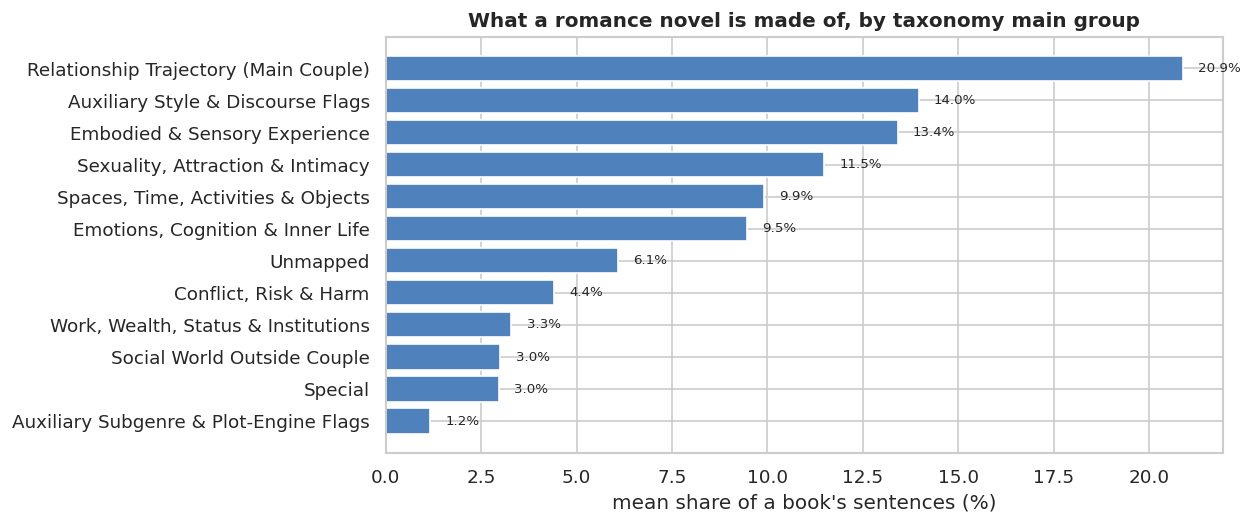

In [2]:
group_profile = pd.DataFrame({
    "group": [GROUP_NAME.get(c, c) for c in GROUP_COLS],
    "feature": GROUP_COLS,
    "mean_share": [frame[c].mean() for c in GROUP_COLS],
    "median_share": [frame[c].median() for c in GROUP_COLS],
    "sd_share": [frame[c].std() for c in GROUP_COLS],
}).sort_values("mean_share", ascending=False)
group_profile["n_leaves"] = group_profile["group"].map(
    leaf_meta.groupby("main_group")["leaf_id"].size()
).fillna(0).astype(int)
group_profile["n_topics"] = group_profile["group"].map(
    leaf_meta.groupby("main_group")["n_topics"].sum()
).fillna(0).astype(int)

display(nbh.share_as_percent(group_profile, ["mean_share", "median_share", "sd_share"]).round(2))
ctx.save_table(group_profile, "main_group_profile")

fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = group_profile.sort_values("mean_share")
ax.barh(ordered["group"], ordered["mean_share"] * 100, color="#4f81bd")
for y, value in enumerate(ordered["mean_share"] * 100):
    ax.text(value + 0.4, y, f"{value:.1f}%", va="center", fontsize=8)
ax.set_xlabel("mean share of a book's sentences (%)")
ax.set_title("What a romance novel is made of, by taxonomy main group")
ctx.save_figure(fig, "main_group_composition")
plt.show()

## 2. Do the main groups differ across rating tiers?

Twelve tests, corrected as their own family with Benjamini–Hochberg — separate from the
373-topic family in notebook 01, because a small family should not be penalised for the
size of a large one.

Expect small numbers. A main group aggregates dozens of topics that behave differently, so
even a strong topic-level effect gets diluted. Reading these effects as "the domain does not
matter" would be a mistake; they are better read as "the domain as a whole is not the right
unit", which is what sections 3 and 4 pursue.

In [3]:
group_omnibus = tst.kruskal_wallis(frame, GROUP_COLS, TIER_COL, TIERS)
group_omnibus = tst.adjust_within_family(group_omnibus, "p_value", method="fdr_bh", alpha=ALPHA)

group_effects = eff.two_group_effects(
    frame, GROUP_COLS, TIER_COL, HIGH, LOW,
    n_replicates=REPLICATES, seed=int(cfg.section("inference", "bootstrap", "seed")),
)
group_effects = group_effects.merge(
    group_omnibus[["feature", "epsilon_squared", "p_value", "q_value", "q_value_significant"]],
    on="feature", how="left",
)
group_effects["group"] = group_effects["feature"].map(GROUP_NAME)
group_effects["shift_pp"] = group_effects["hodges_lehmann_shift"] * 100
group_effects["reaches_small_effect"] = group_effects["cliffs_delta"].abs() >= GATE

display(group_effects[["group", "cliffs_delta", "ci_low", "ci_high", "magnitude",
                       "shift_pp", "epsilon_squared", "q_value", "reaches_small_effect"]].round(4))
ctx.save_table(group_effects, "main_group_tier_effects")

print(f"\nMain groups reaching at least a small effect (|delta| >= {GATE}): "
      f"{int(group_effects['reaches_small_effect'].sum())} of {len(group_effects)}")
print(nbh.significance_note(int(min((frame[TIER_COL] == t).sum() for t in TIERS))))

,group,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,epsilon_squared,q_value,reaches_small_effect
0,"Conflict, Risk & Harm",0.1368,0.1144,0.1584,small,0.4245,0.0093,0.0000,True
1,Auxiliary Subgenre & Plot-Engine Flags,0.0693,0.0473,0.0928,negligible,0.0585,0.0024,0.0000,False
2,Auxiliary Style & Discourse Flags,0.0538,0.0323,0.0760,negligible,0.2054,0.0018,0.0000,False
3,Social World Outside Couple,0.0487,0.0272,0.0705,negligible,0.1179,0.0012,0.0002,False
4,"Work, Wealth, Status & Institutions",-0.0472,-0.0685,-0.0239,negligible,-0.1108,0.0011,0.0003,False
5,Special,0.0346,0.0126,0.0566,negligible,0.0399,0.0010,0.0006,False
6,Embodied & Sensory Experience,-0.0312,-0.0533,-0.0082,negligible,-0.1484,0.0005,0.0231,False
7,"Spaces, Time, Activities & Objects",0.0216,0.0000,0.0432,negligible,0.0895,0.0002,0.1999,False
8,Unmapped,0.0153,-0.0077,0.0370,negligible,0.0336,0.0001,0.4570,False
9,Relationship Trajectory (Main Couple),0.0127,-0.0101,0.0354,negligible,0.0690,0.0006,0.0184,False


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/main_group_tier_effects.csv  (12 rows)

Main groups reaching at least a small effect (|delta| >= 0.11): 1 of 12
With about 5,086 books per tier, a p-value below 0.05 is nearly automatic: differences far too small to matter still clear the threshold. Read the effect size and its confidence interval, and treat the p-value as a footnote.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/figures/main_group_effects.png


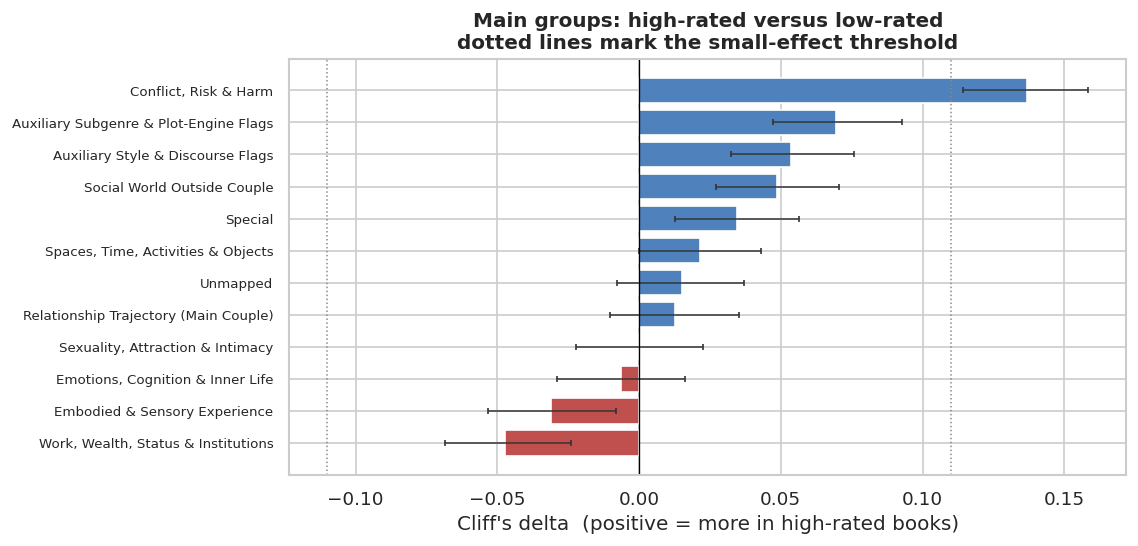

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = group_effects.sort_values("cliffs_delta")
colours = [PALETTE[HIGH] if d > 0 else PALETTE[LOW] for d in ordered["cliffs_delta"]]
y = np.arange(len(ordered))
ax.barh(y, ordered["cliffs_delta"], color=colours)
ax.errorbar(ordered["cliffs_delta"], y,
            xerr=[ordered["cliffs_delta"] - ordered["ci_low"],
                  ordered["ci_high"] - ordered["cliffs_delta"]],
            fmt="none", ecolor="#333333", elinewidth=0.9, capsize=2)
ax.set_yticks(y)
ax.set_yticklabels(ordered["group"], fontsize=8)
ax.axvline(0, color="black", lw=0.8)
for gate_value in (GATE, -GATE):
    ax.axvline(gate_value, color="#888888", ls=":", lw=0.9)
ax.set_xlabel("Cliff's delta  (positive = more in high-rated books)")
ax.set_title("Main groups: high-rated versus low-rated\ndotted lines mark the small-effect threshold")
ctx.save_figure(fig, "main_group_effects")
plt.show()

## 3. Subgroup panels, one per main group

Now the level most romance theory actually speaks at. Leaf shares here are **conditional**:
each leaf's share of a book's *interpretable* mass, excluding noise and unmapped text. That
makes leaves comparable across books that differ in how much of their prose the taxonomy
could label at all.

Each panel below is one main group, showing every leaf inside it with its tier effect. The
tests are corrected within the 45-leaf family, and the panels are just a presentation of
that one corrected set — not 11 separate analyses.

In [5]:
leaf_omnibus = tst.kruskal_wallis(frame, LEAF_COLS, TIER_COL, TIERS)
leaf_omnibus = tst.adjust_within_family(leaf_omnibus, "p_value", method="fdr_bh", alpha=ALPHA)

leaf_effects = eff.two_group_effects(
    frame, LEAF_COLS, TIER_COL, HIGH, LOW,
    n_replicates=REPLICATES, seed=int(cfg.section("inference", "bootstrap", "seed")),
)
leaf_effects = leaf_effects.merge(
    leaf_omnibus[["feature", "epsilon_squared", "p_value", "q_value", "q_value_significant"]],
    on="feature", how="left",
).merge(leaf_meta[["feature", "leaf_id", "leaf_name", "main_group", "n_topics"]],
        on="feature", how="left")
leaf_effects["shift_pp"] = leaf_effects["hodges_lehmann_shift"] * 100
leaf_effects["mean_share_pp"] = leaf_effects[["mean_a", "mean_b"]].mean(axis=1) * 100
leaf_effects["reaches_small_effect"] = leaf_effects["cliffs_delta"].abs() >= GATE
leaf_effects["main_group"] = leaf_effects["main_group"].fillna("(unlabelled)")

print(f"Leaves tested: {len(leaf_effects)}")
print(f"  differ across tiers at BH-FDR q < {ALPHA}: {int(leaf_effects['q_value_significant'].sum())}")
print(f"  reach at least a small effect:            {int(leaf_effects['reaches_small_effect'].sum())}")

leaf_report = leaf_effects.sort_values("cliffs_delta", key=lambda s: s.abs(), ascending=False)
display(leaf_report[["leaf_id", "leaf_name", "main_group", "n_topics", "mean_share_pp",
                     "cliffs_delta", "ci_low", "ci_high", "magnitude", "q_value"]].head(20).round(4))
ctx.save_table(leaf_report, "leaf_tier_effects")

Leaves tested: 45
  differ across tiers at BH-FDR q < 0.05: 32
  reach at least a small effect:            3


,leaf_id,leaf_name,main_group,n_topics,mean_share_pp,cliffs_delta,ci_low,ci_high,magnitude,q_value
0,7.2,"Violence, Threats & Non-Sexual Coercion","Conflict, Risk & Harm",12,2.1066,0.1518,0.1289,0.1742,small,0.0000
1,1.6,Character Appearance & Self-Presentation,Embodied & Sensory Experience,15,3.6838,-0.1466,-0.1682,-0.1237,small,0.0000
2,3.4,"Beliefs, Values & Moral Reflection","Emotions, Cognition & Inner Life",1,0.4070,0.1296,0.1082,0.1511,small,0.0000
3,7.1,Interpersonal Non-Romantic Conflict,"Conflict, Risk & Harm",3,0.4553,0.1044,0.0821,0.1273,negligible,0.0000
4,5.1,"Family, Kinship & Parenthood",Social World Outside Couple,6,2.0943,0.0973,0.0759,0.1185,negligible,0.0000
5,6.5,Institutional Settings & Procedures,"Work, Wealth, Status & Institutions",2,0.5826,0.0971,0.0752,0.1188,negligible,0.0000
6,4.6,"Emotional Safety, Reassurance & Caretaking",Relationship Trajectory (Main Couple),30,8.1301,0.0918,0.0694,0.1145,negligible,0.0000
7,7.4,Unwanted or Coercive Sexual Contact,"Conflict, Risk & Harm",2,0.1505,0.0841,0.0627,0.1052,negligible,0.0000
8,10.3,"Mystery, Suspense & Investigation",Auxiliary Subgenre & Plot-Engine Flags,2,0.2968,0.0808,0.0585,0.1035,negligible,0.0000
9,6.1b,Generic Business / Institutional Negotiation,"Work, Wealth, Status & Institutions",4,1.0737,-0.0788,-0.1014,-0.0560,negligible,0.0000


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/leaf_tier_effects.csv  (45 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/figures/subgroup_panels.png


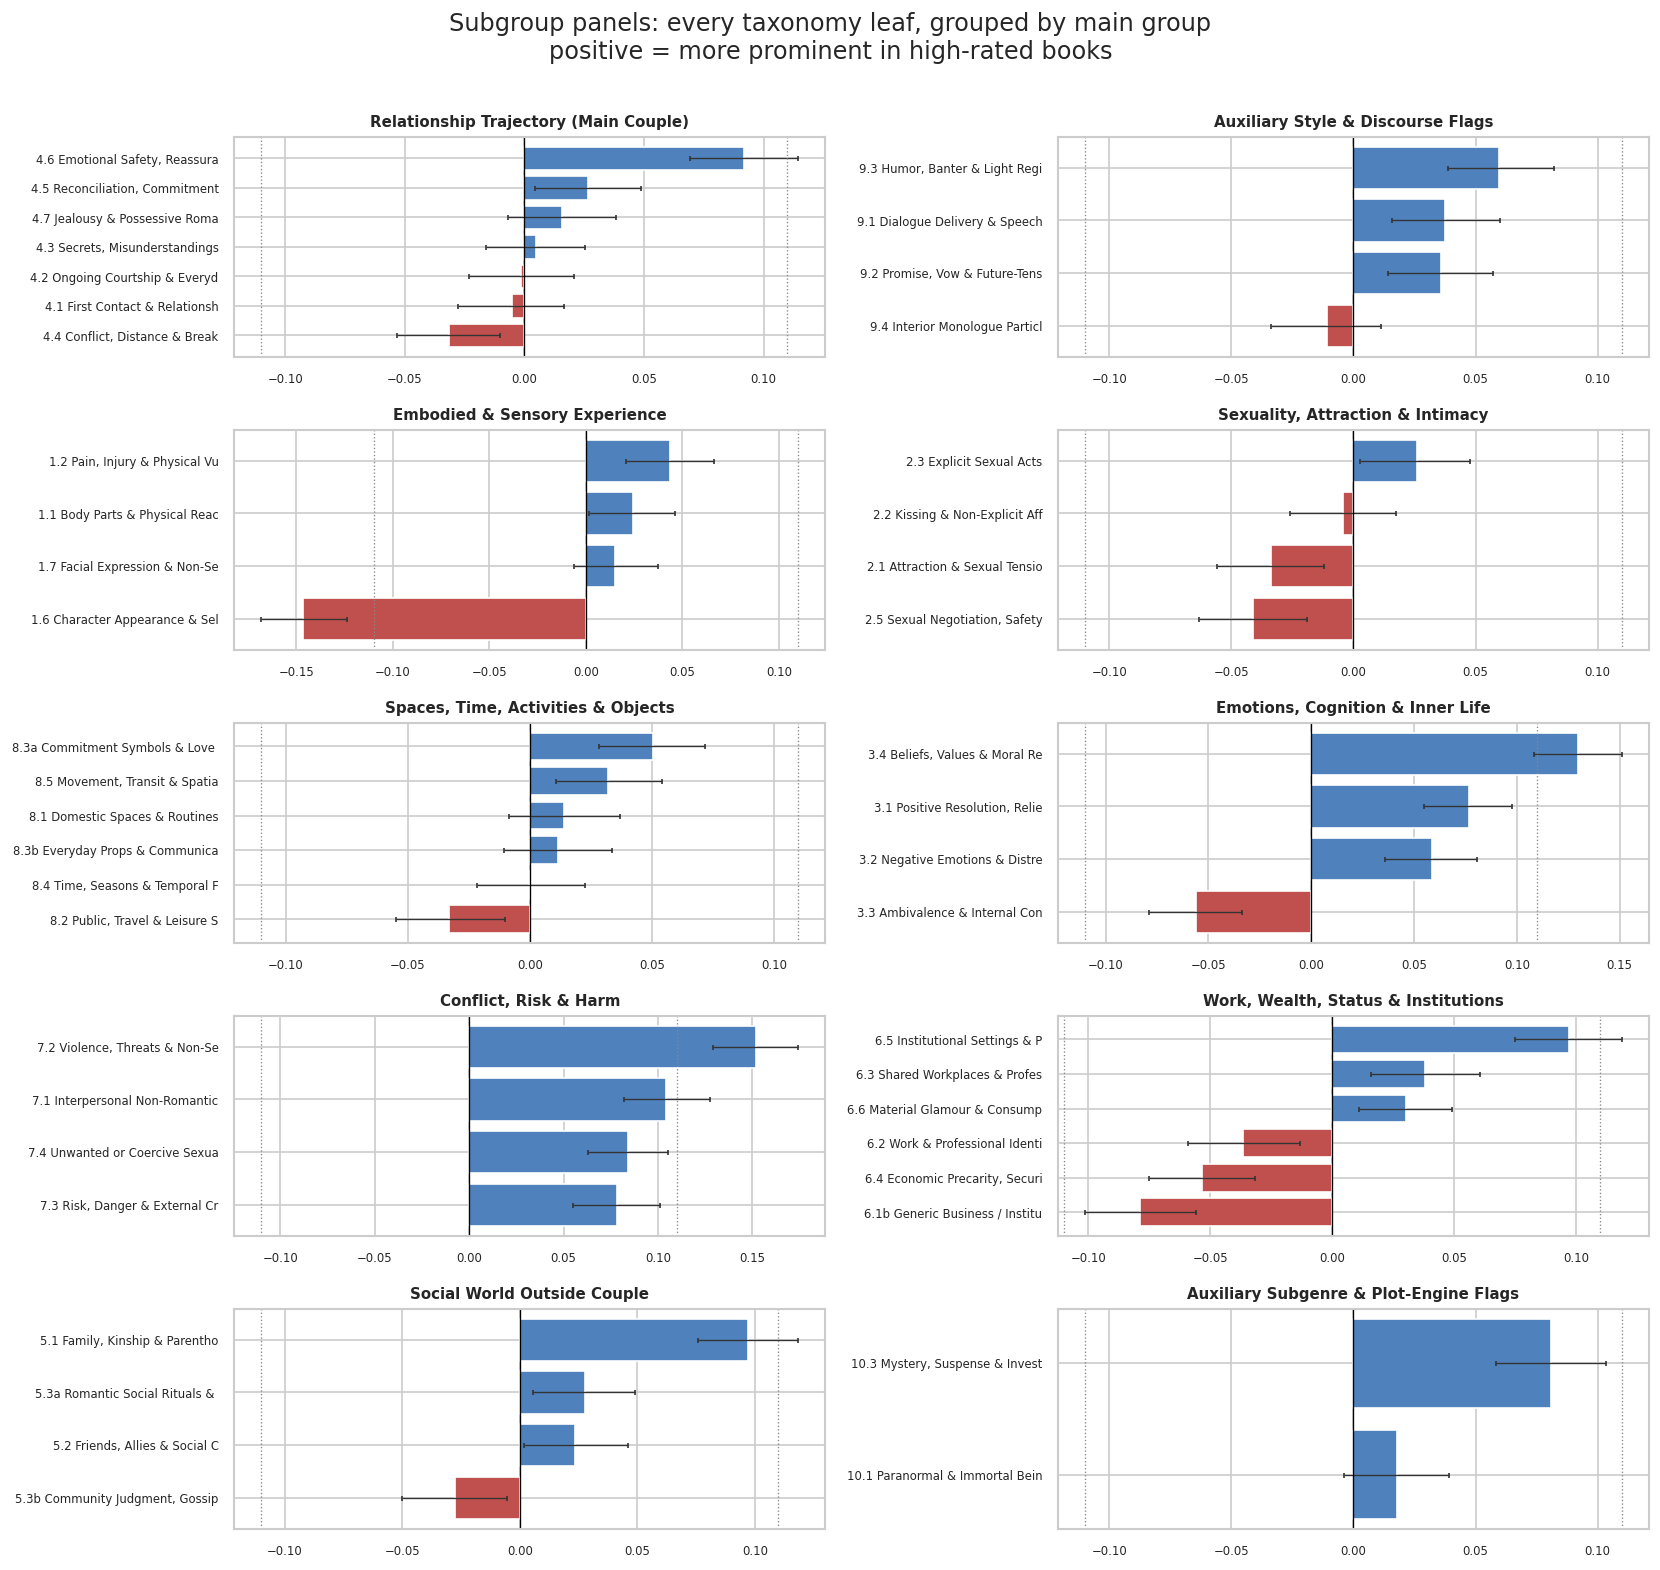

In [6]:
panel_groups = [
    g for g in group_profile["group"]
    if g in set(leaf_effects["main_group"]) and g not in ("Unmapped", "(unlabelled)")
]
n_cols = 2
n_rows = int(np.ceil(len(panel_groups) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.2 * n_rows + 2))
axes = np.atleast_1d(axes).ravel()

for ax, group in zip(axes, panel_groups):
    subset = leaf_effects[leaf_effects["main_group"] == group].sort_values("cliffs_delta")
    colours = [PALETTE[HIGH] if d > 0 else PALETTE[LOW] for d in subset["cliffs_delta"]]
    y = np.arange(len(subset))
    ax.barh(y, subset["cliffs_delta"], color=colours)
    ax.errorbar(subset["cliffs_delta"], y,
                xerr=[subset["cliffs_delta"] - subset["ci_low"],
                      subset["ci_high"] - subset["cliffs_delta"]],
                fmt="none", ecolor="#333333", elinewidth=0.8, capsize=1.5)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{r.leaf_id} {str(r.leaf_name)[:26]}" for r in subset.itertuples()],
                       fontsize=7)
    ax.axvline(0, color="black", lw=0.8)
    for gate_value in (GATE, -GATE):
        ax.axvline(gate_value, color="#888888", ls=":", lw=0.8)
    ax.set_title(str(group)[:48], fontsize=9)
    ax.tick_params(axis="x", labelsize=7)

for ax in axes[len(panel_groups):]:
    ax.axis("off")
fig.suptitle("Subgroup panels: every taxonomy leaf, grouped by main group\n"
             "positive = more prominent in high-rated books", y=1.005)
fig.tight_layout()
ctx.save_figure(fig, "subgroup_panels")
plt.show()

## 4. Did grouping help or hurt?

The diagnostic this chapter exists to run. For each leaf, compare its own tier effect with
the strongest effect among the individual topics inside it.

- **amplifies** — the leaf's effect is at least as strong as its best topic. Pooling worked:
  the member topics agree, and summing them reduced noise.
- **dilutes** — the leaf is much weaker than its best topic. Something inside is cancelling,
  and the leaf total is hiding it.

A leaf that dilutes badly is a signal to go one level back down, which is precisely what
notebook 03 does.

In [7]:
topic_effects = pd.read_csv(
    cfg.notebook_output_dirs("01_topic_landscape")["tables"] / "topic_tier_effects_full.csv"
)
topic_effects["leaf_id"] = topic_effects["taxonomy_main_id"].astype(str)

per_leaf_topics = topic_effects.groupby("leaf_id").agg(
    n_topics_tested=("feature", "size"),
    max_abs_topic_delta=("cliffs_delta", lambda s: float(s.abs().max())),
    mean_topic_delta=("cliffs_delta", "mean"),
    n_topics_positive=("cliffs_delta", lambda s: int((s > 0).sum())),
    n_topics_negative=("cliffs_delta", lambda s: int((s < 0).sum())),
    n_topics_above_gate=("cliffs_delta", lambda s: int((s.abs() >= GATE).sum())),
).reset_index()

aggregation = leaf_effects[["feature", "leaf_id", "leaf_name", "main_group", "cliffs_delta"]].merge(
    per_leaf_topics, on="leaf_id", how="left",
)
aggregation = aggregation[aggregation["n_topics_tested"].notna()].copy()
aggregation["abs_leaf_delta"] = aggregation["cliffs_delta"].abs()
aggregation["retention"] = aggregation["abs_leaf_delta"] / aggregation["max_abs_topic_delta"]
aggregation["sign_split"] = np.minimum(
    aggregation["n_topics_positive"], aggregation["n_topics_negative"]
) / aggregation["n_topics_tested"]
aggregation["verdict"] = np.where(
    aggregation["retention"] >= 1.0, "amplifies",
    np.where(aggregation["retention"] >= 0.6, "preserves", "dilutes"),
)

display(aggregation["verdict"].value_counts().to_frame("n_leaves"))

worst = aggregation[
    (aggregation["n_topics_tested"] >= 3) & (aggregation["verdict"] == "dilutes")
].sort_values("max_abs_topic_delta", ascending=False)
print(f"\nLeaves where pooling loses the most, and where notebook 03 will look first:")
display(worst[["leaf_id", "leaf_name", "main_group", "n_topics_tested", "abs_leaf_delta",
               "max_abs_topic_delta", "retention", "sign_split",
               "n_topics_positive", "n_topics_negative"]].head(12).round(3))
ctx.save_table(aggregation, "aggregation_gain_loss")

,n_leaves
verdict,
dilutes,26
preserves,15
amplifies,4



Leaves where pooling loses the most, and where notebook 03 will look first:


,leaf_id,leaf_name,main_group,n_topics_tested,abs_leaf_delta,max_abs_topic_delta,retention,sign_split,n_topics_positive,n_topics_negative
22,9.2,"Promise, Vow & Future-Tense Speech Acts",Auxiliary Style & Discourse Flags,24,0.0360,0.2250,0.1590,0.2920,17,7
6,4.6,"Emotional Safety, Reassurance & Caretaking",Relationship Trajectory (Main Couple),30,0.0920,0.1600,0.5740,0.1330,26,4
18,2.5,"Sexual Negotiation, Safety Preparation & Bound...","Sexuality, Attraction & Intimacy",7,0.0410,0.1440,0.2870,0.2860,2,5
42,2.2,Kissing & Non-Explicit Affection,"Sexuality, Attraction & Intimacy",4,0.0040,0.1310,0.0330,0.2500,3,1
31,2.3,Explicit Sexual Acts,"Sexuality, Attraction & Intimacy",7,0.0260,0.1310,0.1990,0.4290,4,3
23,2.1,Attraction & Sexual Tension,"Sexuality, Attraction & Intimacy",17,0.0340,0.1300,0.2620,0.3530,11,6
13,3.2,Negative Emotions & Distress,"Emotions, Cognition & Inner Life",14,0.0590,0.1290,0.4530,0.1430,12,2
17,1.2,"Pain, Injury & Physical Vulnerability",Embodied & Sensory Experience,5,0.0440,0.1290,0.3390,0.4000,3,2
32,1.1,Body Parts & Physical Reactions,Embodied & Sensory Experience,7,0.0250,0.1270,0.1940,0.4290,4,3
20,9.1,Dialogue Delivery & Speech Tags,Auxiliary Style & Discourse Flags,6,0.0380,0.1270,0.2980,0.1670,5,1


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/aggregation_gain_loss.csv  (45 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/figures/aggregation_gain_loss.png


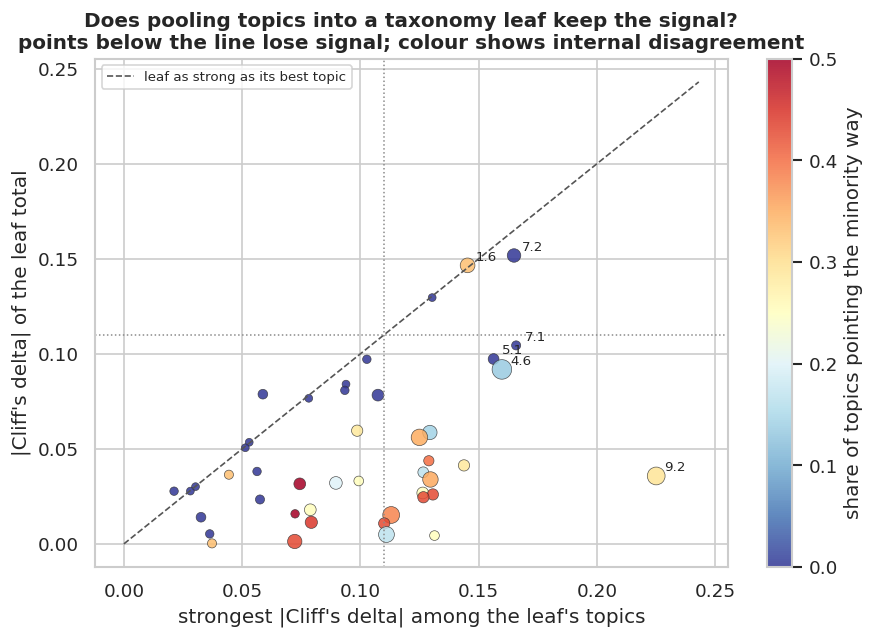

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sizes = 18 + 4 * aggregation["n_topics_tested"].fillna(1)
scatter = ax.scatter(aggregation["max_abs_topic_delta"], aggregation["abs_leaf_delta"],
                     s=sizes, c=aggregation["sign_split"], cmap="RdYlBu_r", alpha=0.85,
                     edgecolor="#333333", linewidth=0.4)
limit = float(max(aggregation["max_abs_topic_delta"].max(), aggregation["abs_leaf_delta"].max())) * 1.08
ax.plot([0, limit], [0, limit], color="#555555", ls="--", lw=1,
        label="leaf as strong as its best topic")
ax.axhline(GATE, color="#888888", ls=":", lw=0.9)
ax.axvline(GATE, color="#888888", ls=":", lw=0.9)
ax.set_xlabel("strongest |Cliff's delta| among the leaf's topics")
ax.set_ylabel("|Cliff's delta| of the leaf total")
ax.set_title("Does pooling topics into a taxonomy leaf keep the signal?\n"
             "points below the line lose signal; colour shows internal disagreement")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(scatter, ax=ax, label="share of topics pointing the minority way")

for _, row in aggregation.nlargest(6, "max_abs_topic_delta").iterrows():
    ax.annotate(f"{row['leaf_id']}", (row["max_abs_topic_delta"], row["abs_leaf_delta"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points")
ctx.save_figure(fig, "aggregation_gain_loss")
plt.show()

## 5. The leaf-level gradient across all three tiers

As in notebook 01, a steady gradient across low → mid → high is a stronger claim than a
single high-versus-low gap. The leaves that both reach a small effect and rise or fall
monotonically are the ones the hypothesis chapters can lean on.

In [9]:
leaf_trend = tst.compare_tier_trend(frame, LEAF_COLS, TIER_COL, TIERS)
leaf_trend = leaf_trend.merge(leaf_meta[["feature", "leaf_id", "leaf_name", "main_group"]],
                              on="feature", how="left")
leaf_trend = leaf_trend.merge(leaf_effects[["feature", "cliffs_delta", "magnitude"]],
                              on="feature", how="left")
leaf_trend["consistent"] = np.sign(leaf_trend["spearman_rho"]) == np.sign(leaf_trend["cliffs_delta"])
leaf_trend["notable"] = leaf_trend["cliffs_delta"].abs() >= GATE

notable = leaf_trend[leaf_trend["notable"]].sort_values(
    "cliffs_delta", key=lambda s: s.abs(), ascending=False
)
print(f"{len(notable)} leaves reach a small effect; "
      f"{int(notable['consistent'].sum())} of them also trend monotonically.")
display(notable[["leaf_id", "leaf_name", "main_group", "cliffs_delta", "spearman_rho",
                 "direction", "consistent"]].round(4))
ctx.save_table(leaf_trend, "leaf_tier_trend")

3 leaves reach a small effect; 3 of them also trend monotonically.


,leaf_id,leaf_name,main_group,cliffs_delta,spearman_rho,direction,consistent
0,7.2,"Violence, Threats & Non-Sexual Coercion","Conflict, Risk & Harm",0.1518,0.1072,rises with rating,True
1,1.6,Character Appearance & Self-Presentation,Embodied & Sensory Experience,-0.1466,-0.1035,falls with rating,True
2,3.4,"Beliefs, Values & Moral Reflection","Emotions, Cognition & Inner Life",0.1296,0.0918,rises with rating,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/leaf_tier_trend.csv  (45 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/figures/leaf_tier_gradients.png


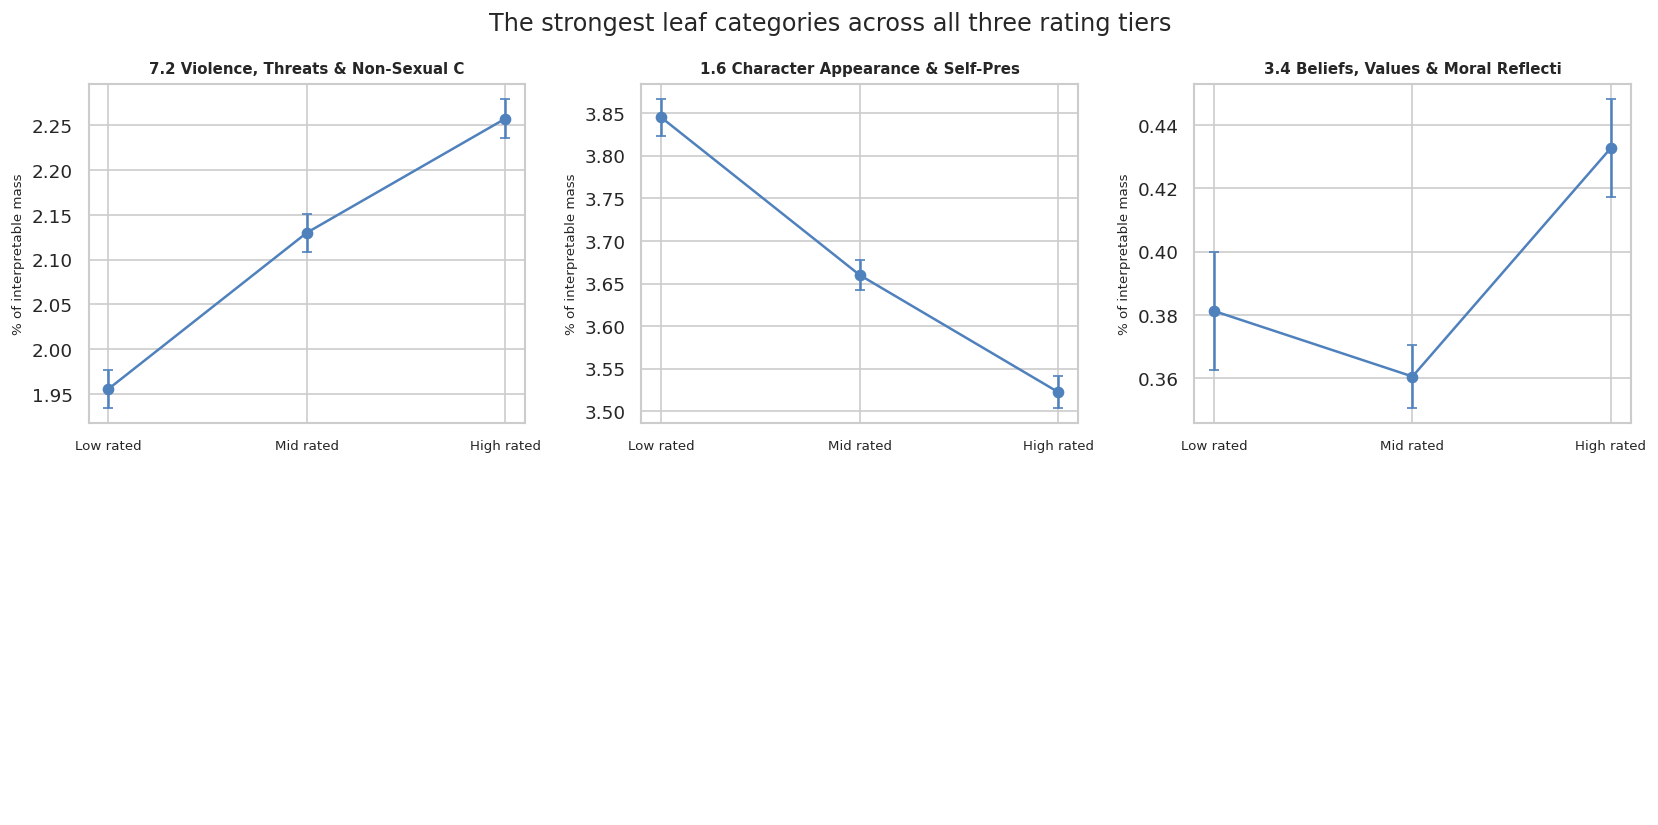

In [10]:
panel_leaves = notable["feature"].head(6).tolist()
if panel_leaves:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.ravel(), panel_leaves):
        means = frame.groupby(TIER_COL, observed=True)[col].mean().reindex(TIERS) * 100
        sems = frame.groupby(TIER_COL, observed=True)[col].sem().reindex(TIERS) * 100
        ax.errorbar(range(len(TIERS)), means.to_numpy(), yerr=sems.to_numpy(),
                    marker="o", color="#4f81bd", capsize=3)
        ax.set_xticks(range(len(TIERS)))
        ax.set_xticklabels([cfg.section("tiers", "labels")[t] for t in TIERS], fontsize=8)
        ax.set_title(f"{col.removeprefix('leaf_')} {str(LEAF_NAME.get(col, ''))[:32]}", fontsize=9)
        ax.set_ylabel("% of interpretable mass", fontsize=8)
    for ax in axes.ravel()[len(panel_leaves):]:
        ax.axis("off")
    fig.suptitle("The strongest leaf categories across all three rating tiers")
    fig.tight_layout()
    ctx.save_figure(fig, "leaf_tier_gradients")
    plt.show()

## 6. How the levels compare

One table, three levels of granularity, same corpus and same contrast. This is the honest
summary of what resolution the signal lives at.

In [11]:
levels = pd.DataFrame([
    ("topics (373)", len(topic_effects),
     int((topic_effects["cliffs_delta"].abs() >= GATE).sum()),
     float(topic_effects["cliffs_delta"].abs().max())),
    ("taxonomy leaves (45)", len(leaf_effects),
     int(leaf_effects["reaches_small_effect"].sum()),
     float(leaf_effects["cliffs_delta"].abs().max())),
    ("main groups (12)", len(group_effects),
     int(group_effects["reaches_small_effect"].sum()),
     float(group_effects["cliffs_delta"].abs().max())),
], columns=["level", "n_features", "n_reaching_small_effect", "strongest_abs_delta"])
display(levels.round(4))
ctx.save_table(levels, "granularity_comparison")

summary = pd.DataFrame([
    ("largest main group", f"{group_profile.iloc[0]['group']} "
                           f"({group_profile.iloc[0]['mean_share']:.1%} of sentences)"),
    ("main groups with a small effect", f"{int(group_effects['reaches_small_effect'].sum())} of {len(group_effects)}"),
    ("leaves with a small effect", f"{int(leaf_effects['reaches_small_effect'].sum())} of {len(leaf_effects)}"),
    ("strongest leaf", f"{leaf_report.iloc[0]['leaf_id']} {leaf_report.iloc[0]['leaf_name']} "
                       f"(delta = {leaf_report.iloc[0]['cliffs_delta']:+.3f})"),
    ("leaves that amplify their topics", f"{int((aggregation['verdict'] == 'amplifies').sum())}"),
    ("leaves that dilute their topics", f"{int((aggregation['verdict'] == 'dilutes').sum())}"),
    ("leaves both notable and monotone", f"{int(notable['consistent'].sum())} of {len(notable)}"),
], columns=["item", "value"])
display(summary)
ctx.save_table(summary, "chapter_summary")

print("\nNext: 03_within_subgroup_drivers.ipynb — inside the categories that matter, which")
print("individual topics carry the difference, and which cancel each other out.")

,level,n_features,n_reaching_small_effect,strongest_abs_delta
0,topics (373),369,38,0.2251
1,taxonomy leaves (45),45,3,0.1518
2,main groups (12),12,1,0.1368


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/granularity_comparison.csv  (3 rows)


,item,value
0,largest main group,Relationship Trajectory (Main Couple) (20.9% o...
1,main groups with a small effect,1 of 12
2,leaves with a small effect,3 of 45
3,strongest leaf,"7.2 Violence, Threats & Non-Sexual Coercion (d..."
4,leaves that amplify their topics,4
5,leaves that dilute their topics,26
6,leaves both notable and monotone,3 of 3


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/02_taxonomy_structure/tables/chapter_summary.csv  (7 rows)

Next: 03_within_subgroup_drivers.ipynb — inside the categories that matter, which
individual topics carry the difference, and which cancel each other out.
